In [1]:
#from pybird.greenfunction import GreenFunction
from pybird_master.greenfunction import GreenFunction as master_GreenFunction
from pybird_w0wa.greenfunction import GreenFunction

import numpy as np 
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['axes.titlesize'] = 30

In [2]:
w0 = [-1.,-.3,-.9,-.9,-0.45,-0.45,-0.45]
wa = [0.,0.,0.,0.,-1.8,-1.8,-1.2]
# wa = [0.,0.,0.,0.,0.,0.,0.]
quin = [False,True,False,True,False,True,True]

# w0 = [-1.2,-1.2,-1.2,-1.2,-1.3,-1.4]
# wa = [-0.,-0.1,-0.8,-1.8,-1.8,-1.8]
# quin = [True,True,True,True,True,True,True]


case = []
for i in range(len(w0)):
    if w0[i]==-1. and wa[i]==0.:
        case.append(r'$\Lambda$CDM')
    elif w0[i]!=-1. and wa[i]==0. :
        if quin[i]:
            case.append('w={} cq'.format(w0[i]))
        else:
            case.append('w={}'.format(w0[i]))
    else:
        if quin[i]:
            case.append('w0={},wa={} cq'.format(w0[i],wa[i]))
        else:
            case.append('w0={},wa={}'.format(w0[i],wa[i]))

# case = [r'$\Lambda$CDM',r'$w=-2$',r'$w=-0.9$',r'$w=-0.9$ cq',
#         r'$w_0=-0.45,w_a=-1.8$',r'$w_0=-0.45,w_a=-1.8$ cq',
#         r'$w_0=-0.45,w_a=-1.2$ cq']
color = ['k','violet','green','purple','red','blue',
         'darkblue'
        ]

Omega0_m = 0.3

x = np.linspace(-3,0,100)
a = np.exp(x)

In [3]:
# mGF = master_GreenFunction(Omega0_m,w=-1.,quintessence=False)
# mG1t = np.array([mGF.mG1t(ai) for ai in a])
# mG = np.array([mGF.G(ai) for ai in a])
# mY = np.array([mGF.Y(ai) for ai in a])


#mGF = master_GreenFunction(Omega0_m,w=-1.,quintessence=False)
mG1t = np.array([3/7 for ai in a])
mG = np.array([1 for ai in a])
mY = np.array([0 for ai in a])


In [5]:





num = {}
ana = {}
master = {}
for i in range(len(w0)):
    name = 'w0={},wa={},quin={}'.format(w0[i],wa[i],quin[i])

    num[name]={}
    ana[name]={}
    master[name]={}
    
    
    num[name]['GF'] = GreenFunction(Omega0_m,w=w0[i],wa=wa[i],quintessence=quin[i])
    #ana[name]['GF'] = ana_GreenFunction(Omega0_m,w0=w0[i],wa=wa[i],quintessence=quin[i],correct_ab=True)

    master[name]['GF'] = master_GreenFunction(Omega0_m,w=w0[i],wa=wa[i],quintessence=quin[i])


/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/jax/_src/core.py:678: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. 

In [6]:
np.log(1/(1+5))

-1.791759469228055

In [7]:
for i in range(len(w0)):
    
    name = 'w0={},wa={},quin={}'.format(w0[i],wa[i],quin[i])
    num[name]['G1th'] = np.array([num[name]['GF'].mG1t(ai) for ai in a])
    num[name]['G'] = np.array([num[name]['GF'].G(ai) for ai in a])
    num[name]['f'] = np.array([num[name]['GF'].fplus(xi) for xi in x])
    num[name]['Dq2'] = np.array([num[name]['GF'].D(xi)/num[name]['GF'].D(np.log(1/(1+5.))) for xi in x])**2
    

    # ana[name]['G1th'] = np.array([ana[name]['GF'].mG1t(ai) for ai in a])
    # ana[name]['G'] = np.array([ana[name]['GF'].G(ai) for ai in a])

    master[name]['G1th'] = np.array([master[name]['GF'].mG1t(ai) for ai in a])
    master[name]['G'] = np.array([master[name]['GF'].G(ai) for ai in a])
    master[name]['f'] = np.array([master[name]['GF'].fplus(ai) for ai in a])
    master[name]['Dq2'] = np.array([master[name]['GF'].D(ai)/master[name]['GF'].D(1/(1+5.)) for ai in a])**2
    master[name]['Y'] = np.array([master[name]['GF'].Y(ai) for ai in a])
    
    

# compare with master

Text(0.5, 0.98, 'numerical/master')

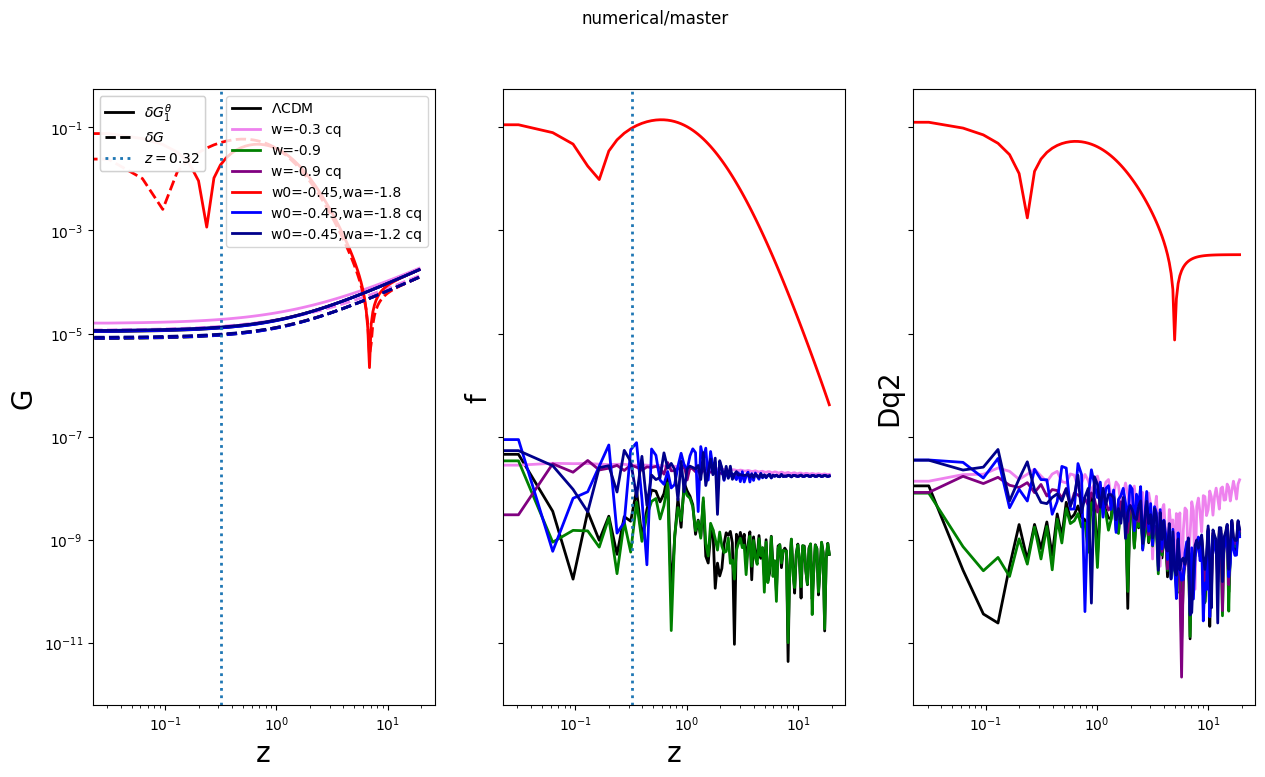

In [8]:
z = 1/a-1
f,ax = plt.subplots(1,3,figsize=(15,8),sharey=True,sharex=True)

leg = []
leg2 = []
for i in range(len(w0)):
    name = 'w0={},wa={},quin={}'.format(w0[i],wa[i],quin[i])
    l1, = ax[0].plot(z,abs(num[name]['G1th']/master[name]['G1th']-1),color=color[i],label=case[i])
    l2, = ax[0].plot(z,abs(num[name]['G']/master[name]['G']-1),color=color[i],linestyle='--',label=name)
    ax[1].plot(z,abs(num[name]['f']/master[name]['f']-1),color=color[i],label=case[i])
    ax[2].plot(z,abs(num[name]['Dq2']/master[name]['Dq2']-1),color=color[i],label=case[i])
    leg.append(l1)
    leg2.append(l2)

    

ax[0].loglog()
ax[0].set_xlabel('z')
ax[1].set_xlabel('z')
ax[0].set_ylabel('G')
ax[1].set_ylabel('f')
ax[2].set_ylabel('Dq2')


leg1=ax[0].legend(handles=leg,loc=1, ncol=1)
ax[0].add_artist(leg1)


lv = ax[0].axvline(0.32,linestyle=':',label='z=0.32')
ax[1].axvline(0.32,linestyle=':')
legbase = ax[0].legend([leg[0],leg2[0],lv],[r'$\delta G_1^\theta$',r'$\delta G$',r'$z=0.32$'],loc=2)
ax[0].add_artist(legbase)

f.suptitle('numerical/master')
#plt.savefig('numerical/master.pdf',dpi=300)

Text(0.5, 0.98, 'numerical/master')

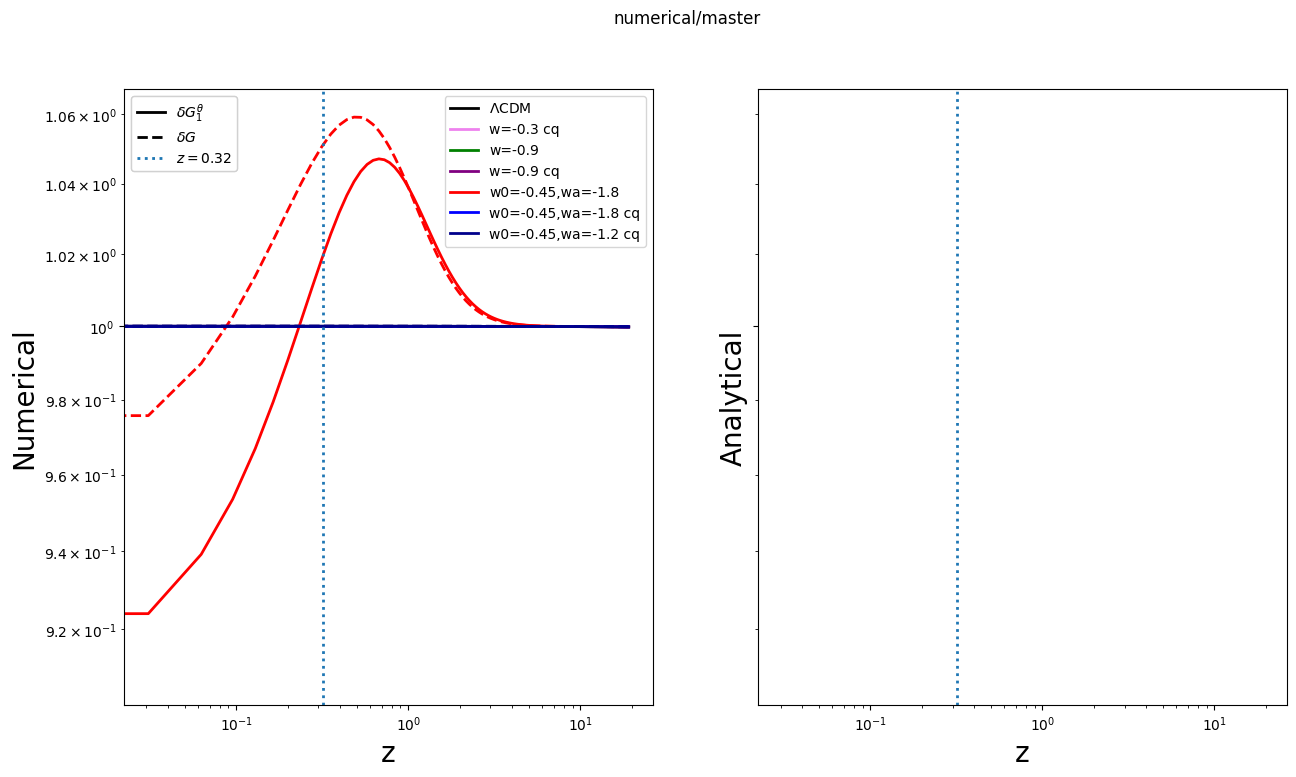

In [9]:
z = 1/a-1
f,ax = plt.subplots(1,2,figsize=(15,8),sharey=True,sharex=True)

leg = []
leg2 = []
for i in range(len(w0)):
    name = 'w0={},wa={},quin={}'.format(w0[i],wa[i],quin[i])
    l1, = ax[0].plot(z,abs(num[name]['G1th']/master[name]['G1th']),color=color[i],label=case[i])
    l2, = ax[0].plot(z,abs(num[name]['G']/master[name]['G']),color=color[i],linestyle='--',label=name)
    
    leg.append(l1)
    leg2.append(l2)

    

ax[0].loglog()
ax[0].set_xlabel('z')
ax[1].set_xlabel('z')
ax[0].set_ylabel('Numerical')
ax[1].set_ylabel('Analytical')


leg1=ax[0].legend(handles=leg,loc=1, ncol=1)
ax[0].add_artist(leg1)


lv = ax[0].axvline(0.32,linestyle=':',label='z=0.32')
ax[1].axvline(0.32,linestyle=':')
legbase = ax[0].legend([leg[0],leg2[0],lv],[r'$\delta G_1^\theta$',r'$\delta G$',r'$z=0.32$'],loc=2)
ax[0].add_artist(legbase)
f.suptitle('numerical/master')

#plt.savefig('numerical-analytical-G.pdf',dpi=300)

# compare within pybirdd

Text(0.5, 0.98, 'cases/eds')

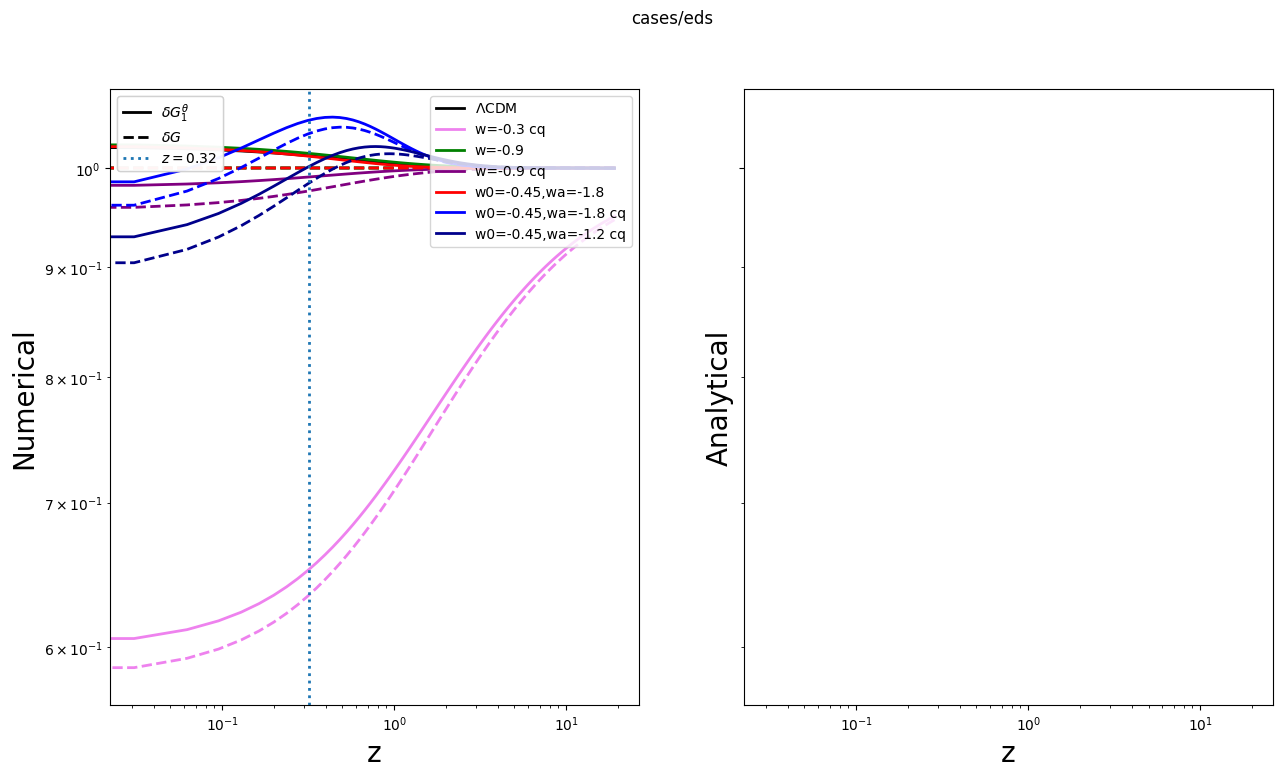

In [10]:
z = 1/a-1
f,ax = plt.subplots(1,2,figsize=(15,8),sharey=True,sharex=True)

leg = []
leg2 = []
for i in range(len(w0)):
    name = 'w0={},wa={},quin={}'.format(w0[i],wa[i],quin[i])
    l1, = ax[0].plot(z,abs(num[name]['G1th']/mG1t),color=color[i],label=case[i])
    l2, = ax[0].plot(z,abs(num[name]['G']/mG),color=color[i],linestyle='--',label=name)
    
    leg.append(l1)
    leg2.append(l2)

    

ax[0].loglog()
ax[0].set_xlabel('z')
ax[1].set_xlabel('z')
ax[0].set_ylabel('Numerical')
ax[1].set_ylabel('Analytical')


leg1=ax[0].legend(handles=leg,loc=1, ncol=1)
ax[0].add_artist(leg1)


lv = ax[0].axvline(0.32,linestyle=':',label='z=0.32')
#ax[1].axvline(0.32,linestyle=':')
legbase = ax[0].legend([leg[0],leg2[0],lv],[r'$\delta G_1^\theta$',r'$\delta G$',r'$z=0.32$'],loc=2)
ax[0].add_artist(legbase)
f.suptitle('cases/eds')

#plt.savefig('numerical-analytical-G.pdf',dpi=300)

In [11]:
1/0.96

1.0416666666666667

Text(0.5, 0.98, 'cases/eds-1')

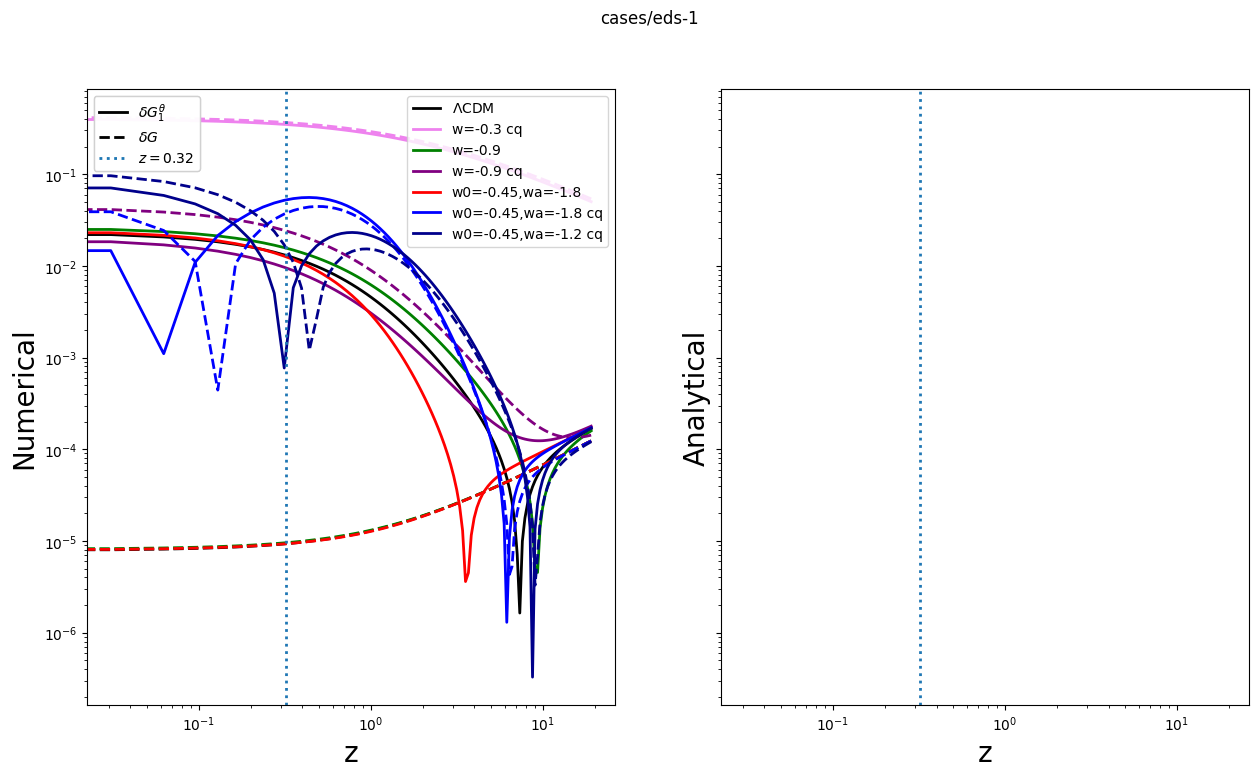

In [12]:
z = 1/a-1
f,ax = plt.subplots(1,2,figsize=(15,8),sharey=True,sharex=True)

leg = []
leg2 = []
for i in range(len(w0)):
    name = 'w0={},wa={},quin={}'.format(w0[i],wa[i],quin[i])
    l1, = ax[0].plot(z,abs(num[name]['G1th']/mG1t-1),color=color[i],label=case[i])
    l2, = ax[0].plot(z,abs(num[name]['G']/mG-1),color=color[i],linestyle='--',label=name)
    
    leg.append(l1)
    leg2.append(l2)

# for i in range(len(w0)):
#     name = 'w0={},wa={},quin={}'.format(w0[i],wa[i],quin[i])
#     ax[1].plot(z,abs(ana[name]['G1th']/mG1t-1),color=color[i],label=name)
#     ax[1].plot(z,abs(ana[name]['G']/mG-1),color=color[i],linestyle='--',label=name)
    

ax[0].loglog()
ax[0].set_xlabel('z')
ax[1].set_xlabel('z')
ax[0].set_ylabel('Numerical')
ax[1].set_ylabel('Analytical')


leg1=ax[0].legend(handles=leg,loc=1, ncol=1)
ax[0].add_artist(leg1)


lv = ax[0].axvline(0.32,linestyle=':',label='z=0.32')
ax[1].axvline(0.32,linestyle=':')
legbase = ax[0].legend([leg[0],leg2[0],lv],[r'$\delta G_1^\theta$',r'$\delta G$',r'$z=0.32$'],loc=2)
ax[0].add_artist(legbase)

f.suptitle('cases/eds-1')
#plt.savefig('numerical-analytical-G.pdf',dpi=300)

## Y

In [13]:
for i in range(len(w0)):
    
    name = 'w0={},wa={},quin={}'.format(w0[i],wa[i],quin[i])
    num[name]['Y'] = np.array([num[name]['GF'].Y(ai) for ai in a])
    

    
    


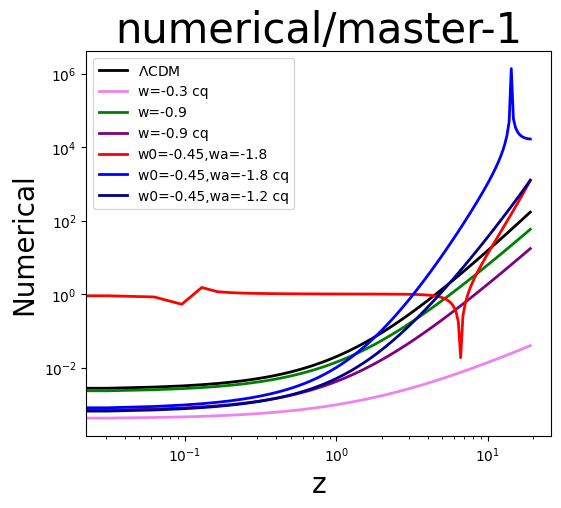

In [14]:
#plt.subplot(figsize=(20,10))
plt.figure(figsize=(6,5))

for i in range(len(w0)):
    
    name = 'w0={},wa={},quin={}'.format(w0[i],wa[i],quin[i])


    plt.plot(z,abs(num[name]['Y']/master[name]['Y']-1),color=color[i],label=case[i])

plt.ylabel('Numerical')
plt.loglog()
plt.xlabel('z')

# legy = plt.legend(ly1,['Y'])
# plt.gca().add_artist(legy)
plt.title('numerical/master-1')
plt.legend(ncol=1)
#plt.savefig('numerical-Y.pdf',dpi=300)

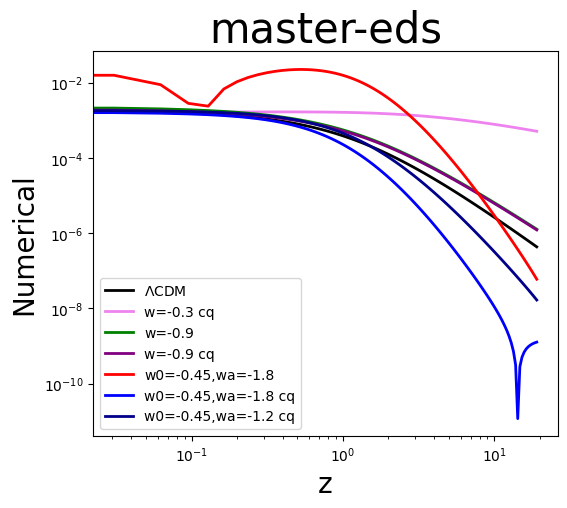

In [15]:
#plt.subplot(figsize=(20,10))
plt.figure(figsize=(6,5))

for i in range(len(w0)):
    
    name = 'w0={},wa={},quin={}'.format(w0[i],wa[i],quin[i])


    plt.plot(z,abs(master[name]['Y']),color=color[i],label=case[i])

plt.ylabel('Numerical')
plt.loglog()
plt.xlabel('z')

# legy = plt.legend(ly1,['Y'])
# plt.gca().add_artist(legy)
plt.title('master-eds')
plt.legend(ncol=1)

#plt.savefig('numerical-Y.pdf',dpi=300)

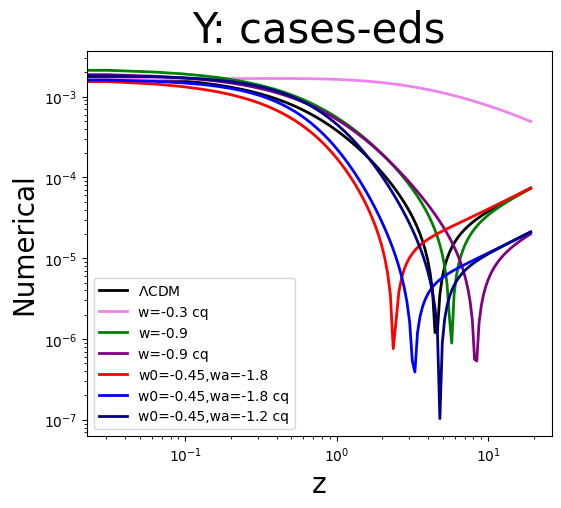

In [16]:
#plt.subplot(figsize=(20,10))
plt.figure(figsize=(6,5))

for i in range(len(w0)):
    
    name = 'w0={},wa={},quin={}'.format(w0[i],wa[i],quin[i])


    plt.plot(z,abs(num[name]['Y']),color=color[i],label=case[i])

plt.ylabel('Numerical')
plt.loglog()
plt.xlabel('z')

# legy = plt.legend(ly1,['Y'])
# plt.gca().add_artist(legy)
plt.title('Y: cases-eds')
plt.legend(ncol=1)

#plt.savefig('numerical-Y.pdf',dpi=300)